In [ ]:
from PIL import Image #Pillow is used to open , manipulate and save the image in different format, the Image modules is imported to due various types of manipulation to the image
from skimage.io import imread, imshow, show #skimage is collection of algorithms that is used for image processing, skimage.io is used for reading(imread), displaying(imshow), show the plotted image in different screen(show) and saving images and videos
import scipy.fftpack as fp #scipy library function for fast fourier transforms which is used for frequency analysis and filtering the signal and image processing
from scipy import ndimage, misc, signal #ndimage and signal - used for multidimensional image processing, misc- for miscellaneous functions
#from scipy.stats import signaltonoise
from skimage import data, img_as_float # data - provides the built-in sample images and datsets, img_as_float - converts the image to floating point representation
from skimage.color import rgb2gray # converts the image (RGB) to grayscale
from skimage.transform import rescale # rescale an image by scaling factor
import matplotlib.pylab as pylab # it combines the functionality of pyplot and numpy
import matplotlib.pyplot as plt # standard interface to build various types of plot
import numpy as np # for the numerial computations on arrays
import numpy.fft # functions for performing fast fourier transform - frequncy domain analysis
import timeit # used for measuring the execution time of code

(-0.5, 106.5, 104.5, -0.5)

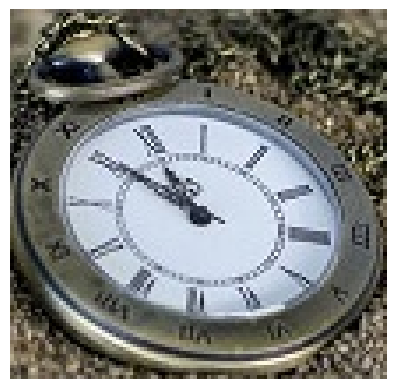

In [ ]:
im = Image.open("clock.jpg") # the original small clock image
pylab.imshow(im)
plt.axis("off")

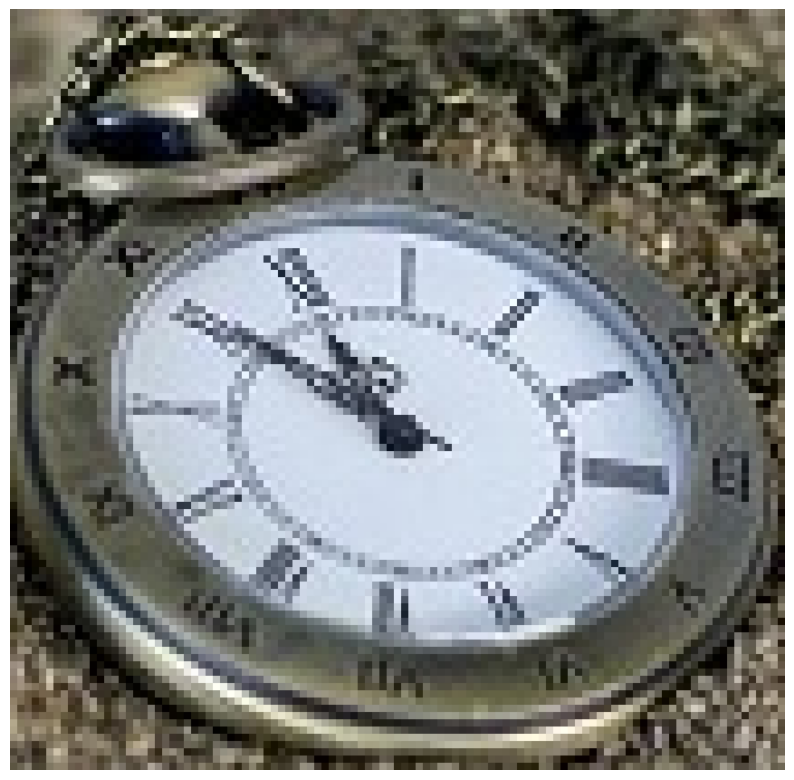

In [ ]:
#up sampling of image
im1 = im.resize((im.width*5, im.height*5), Image.NEAREST) # nearest neighbor interpolation
#up-scales the image by 5x, the generated image is pixelated as nearest neighbor interpolation assigns the value of closest pixel in the original image to each pixel in resized image.
pylab.figure(figsize=(10,10))
plt.axis("off")
pylab.imshow(im1)

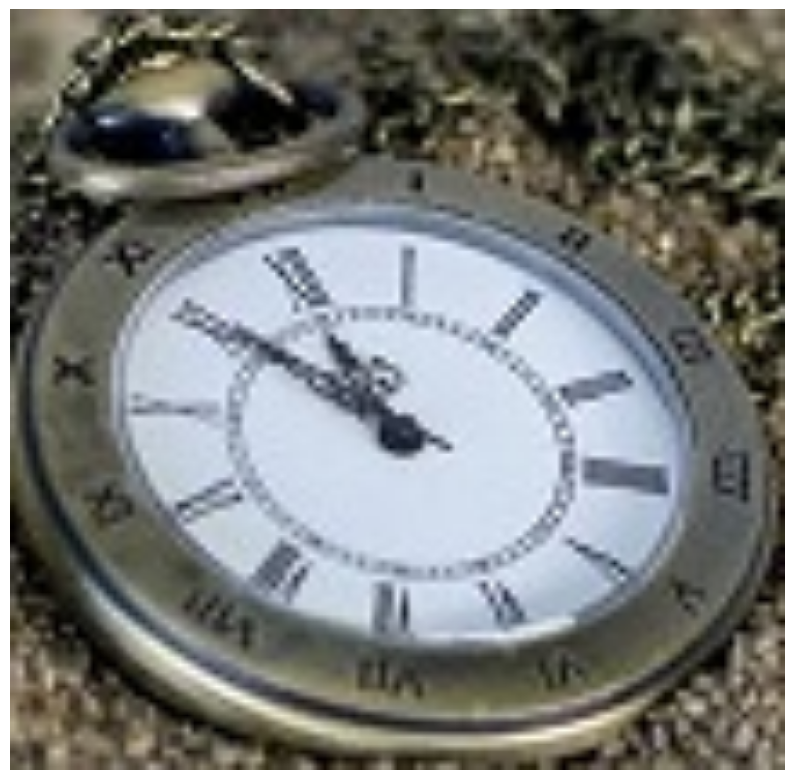

In [ ]:
im1 = im.resize((im.width*5, im.height*5), Image.BILINEAR) # up-sample with bi-linear interpolation
#bi-linear interpolation calcuates the pixel value in resized image by taking the weighted average of the 4 nearest pixels in original image, smoother than nearest neighbor
pylab.figure(figsize=(10,10))
plt.axis("off")
pylab.imshow(im1)

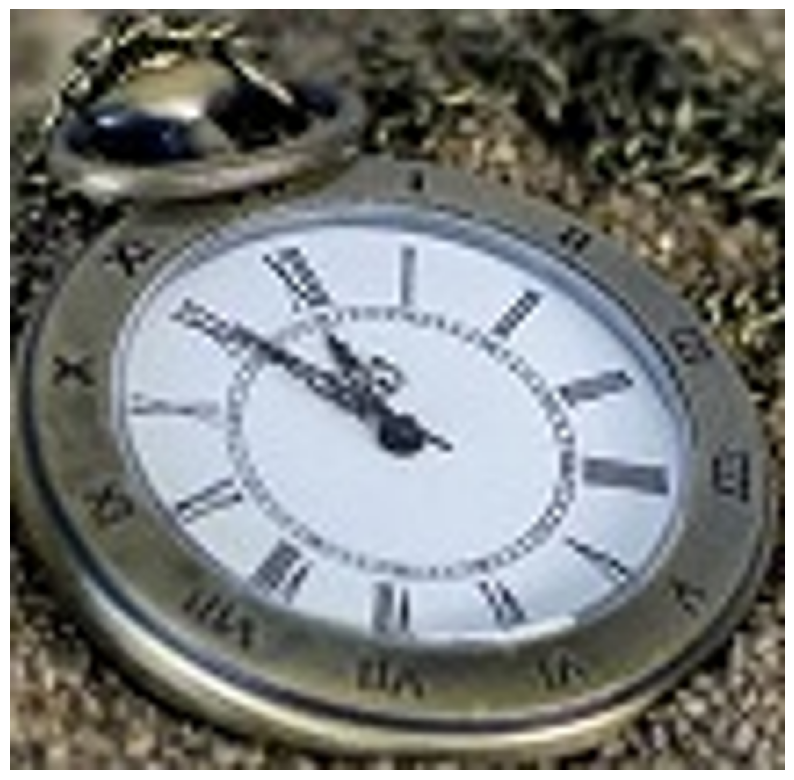

In [ ]:
im1 = im.resize((im.width*5, im.height*5), Image.BICUBIC) # bi-cubic interpolation
#bi-cubic interpolation caluculates the pixel value by weighted average of 16 nearest pixel, by applying the cubic function for smoother transitions
pylab.figure(figsize=(10,10))
plt.axis("off")
pylab.imshow(im1)

Down-sampling

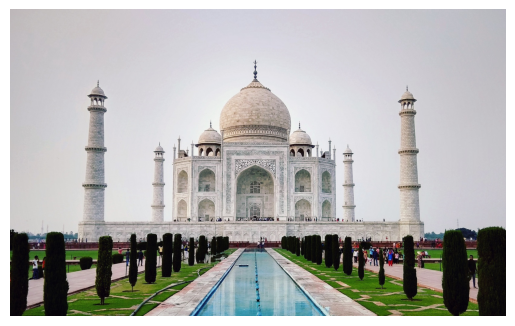

In [ ]:
im = Image.open("tajmahal.jpg")
plt.axis("off")
plt.imshow(im)

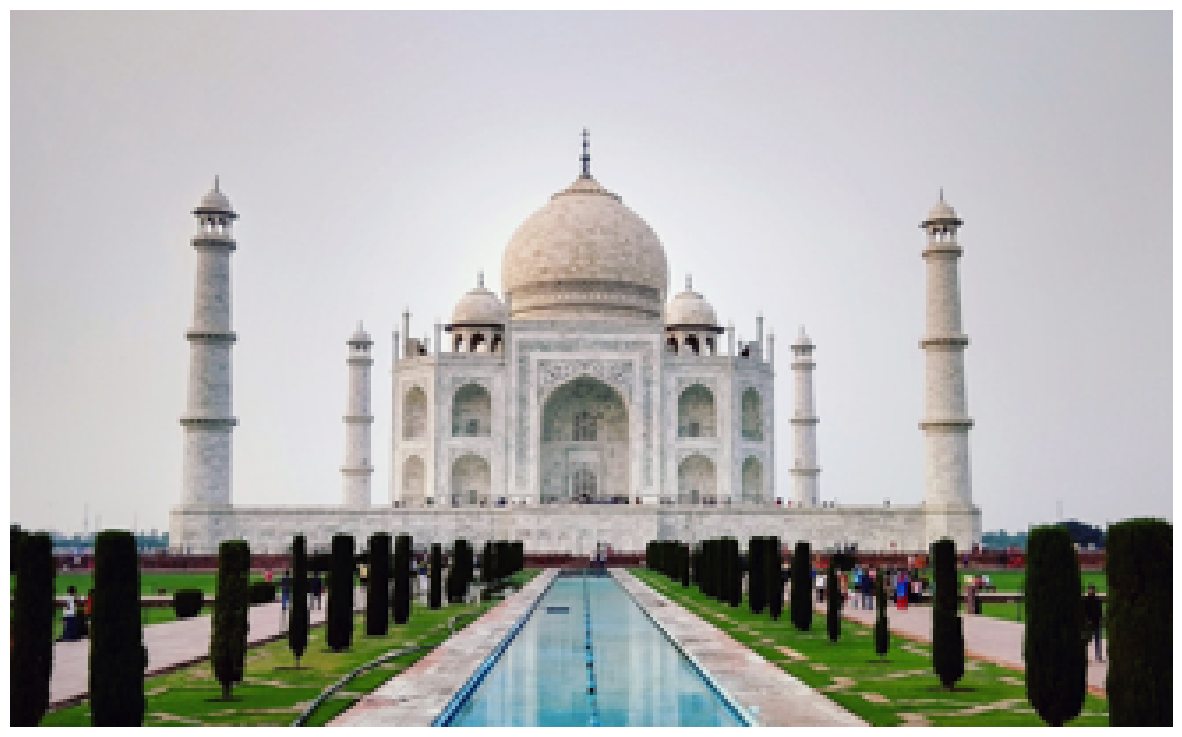

In [ ]:
im1 = im.resize((im.width//5, im.height//5)) # resize(down-scales) the image to 1/5th of its original size
# by default nearest neighbor is used
pylab.figure(figsize=(15,10))
pylab.imshow(im1)
plt.axis("off")
pylab.show()

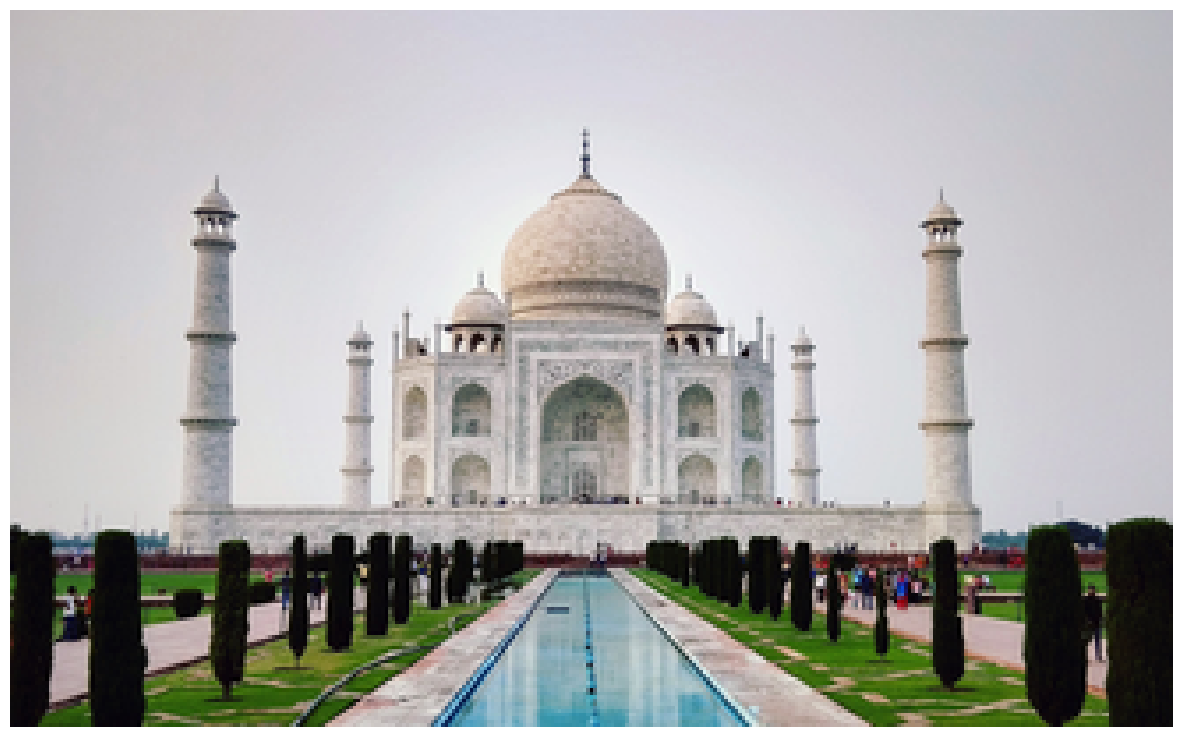

In [ ]:
im1 = im.resize((im.width//5, im.height//5), Image.LANCZOS)#LANCZOS filter is the exact same algorithm that ANTIALIAS referred to
#LANCZOS is used to for apply anti-aliasing that reduces jagged edges-- which can occur when we downsample, resize, rotate or remap the image
pylab.figure(figsize=(15,10))
plt.axis("off")
pylab.imshow(im1)

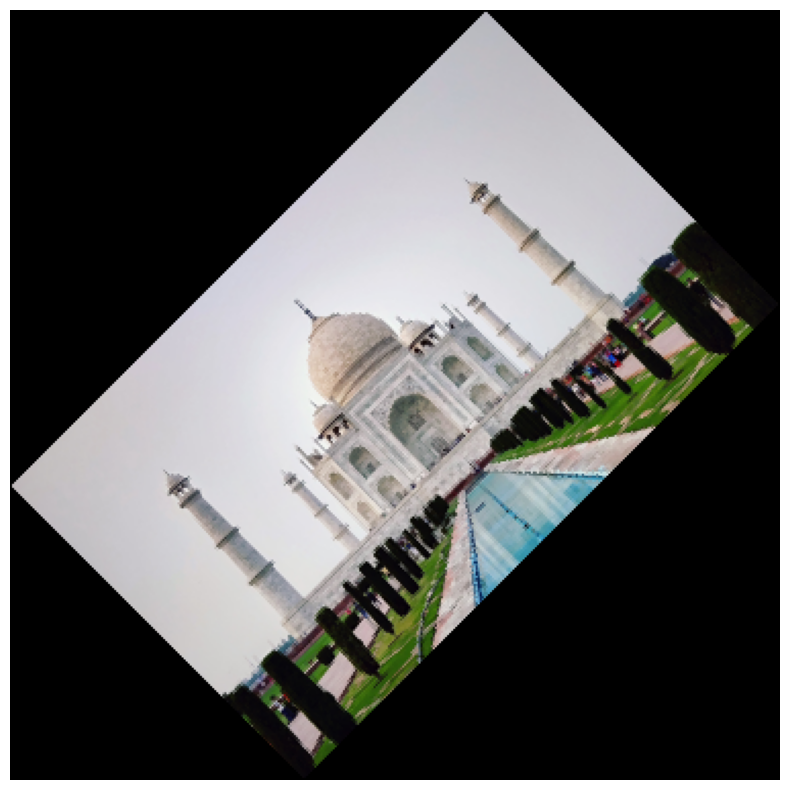

In [ ]:
im1 = im.resize((im.width // 5, im.height // 5)) #downsampled the image
im1 = im1.rotate(45, expand=True) # rotated the image by 45 degrees  to see the ailsing effect in rotation (expand = True is used so that whole image is displayed)
plt.figure(figsize=(15, 10))
plt.imshow(im1)
plt.axis("off")
plt.show()

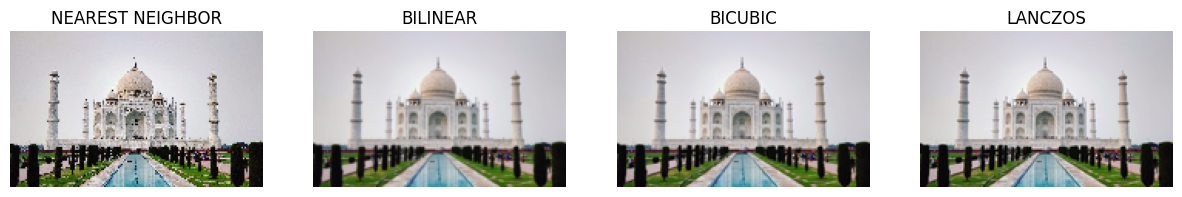

In [ ]:
# Load image
im = Image.open("tajmahal.jpg")

# Resize using different interpolation methods
im_nearest = im.resize((im.width // 10, im.height // 10), Image.NEAREST)  # nearest neighbor method - no anti-aliasing
im_bilinear = im.resize((im.width // 10, im.height // 10), Image.BILINEAR)  # bilinear interpolation - some smoothing
im_bicubic = im.resize((im.width // 10, im.height // 10), Image.BICUBIC)  # bicubic interpolation - better smoothing
im_lanczos = im.resize((im.width // 10, im.height // 10), Image.LANCZOS)  # anti-aliasing by LANCZOS filter

# displayong images side by side
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(im_nearest)
axes[0].set_title("NEAREST NEIGHBOR")
axes[0].axis("off")

axes[1].imshow(im_bilinear)
axes[1].set_title("BILINEAR")
axes[1].axis("off")

axes[2].imshow(im_bicubic)
axes[2].set_title("BICUBIC")
axes[2].axis("off")

axes[3].imshow(im_lanczos)
axes[3].set_title("LANCZOS")
axes[3].axis("off")

plt.show()


## Signal-to-Noise Ratio (SNR)
SNR is the ratio of the power of the signal (useful information) to the power of the noise (undesired interference). A higher SNR indicates a clearer signal, whereas a lower SNR suggests a higher proportion of noise relative to the signal.
It is expressed in **decibels (dB)** using:

![image-3.png](attachment:image-3.png)
![image-2.png](attachment:image-2.png)

Used in **audio, images, and communications** for quality assessment.



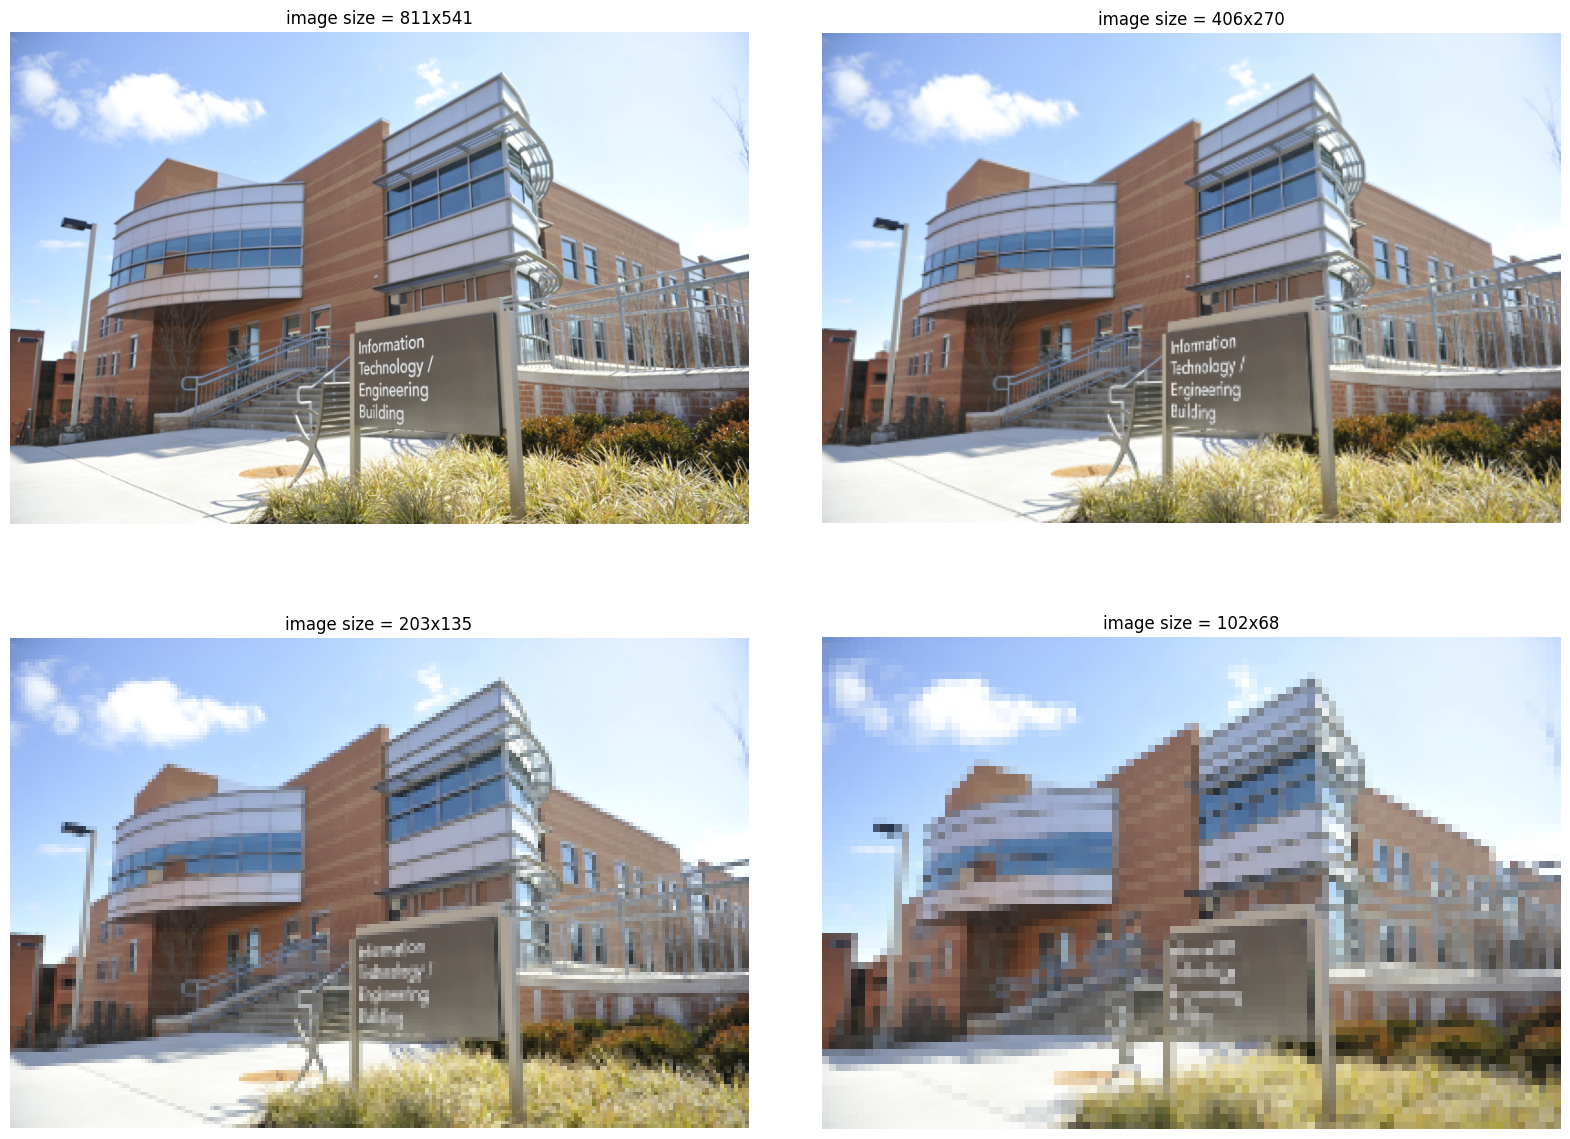

In [ ]:
#from scipy.stats import signaltonoise
im = imread('umbc.png')
im1 = im.copy()
pylab.figure(figsize=(20,15))
for i in range(4):
    pylab.subplot(2,2,i+1) #create a 2x2 grid
    pylab.imshow(im1) #display the current image, removed #cmap= gray as it has almost no effect on and rgb image or an image having more than 1 channel
    pylab.axis('off')
    pylab.title('image size = ' + str(im1.shape[1]) + 'x' + str(im1.shape[0])) #display the image dimension
    #downsamples the image bu 50% in each iteration -- rescale is a function form skimage.transform module to downscale
    im1 = rescale(im1, scale = 0.5, channel_axis=-1, anti_aliasing=False) #ERROR --- added channel-axis instead of multichannel
pylab.subplots_adjust(wspace=0.1, hspace=0.1) #add space between each subplot
pylab.show()


In [ ]:
#im1 = rescale(im1, scale = 0.5, multichannel=True, anti_aliasing=True) #multichannel = True tells that image has multiple channels (whixh is now outdated)
im1 = rescale(im1, scale = 0.5, channel_axis=-1, anti_aliasing=True) #channel-axis = -1 specifies that the last axis of array represents the color channel


In [ ]:
def signaltonoise(a, axis=0, ddof=0): # a is the input array, axis = 0
    a = np.asanyarray(a)
    m = a.mean(axis) #mean value of array a along the axis = 0, which represents the signals
    sd = a.std(axis=axis, ddof=ddof) # used to represnt the noise int the data
    return np.where(sd == 0, 0, m/sd) # where function is used handle the case when standard deviation is zero, the function
                                    # should return 0(as the SNR is undefined or infinite as sd is in denominator) otherwiae it should return
                                    # the m/sd -- which is the signal to noise ratio

### QUANTIZATION
im1 = im.convert('P', palette=Image.ADAPTIVE, colors=num_colors) ---->
the line of code performs color quantization by converting the image to a reduced color palette, which is a type of quantization where the number of available colors is limited to a predefined numbe

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\anany\AppData\Local\Temp\ipykernel_32552\223771108.py:1: SyntaxWarning: invalid escape sequence '\C'
  im = Image.open('D:\College_IIITL\Sem 2\IPCV\images\parrot.jpg')


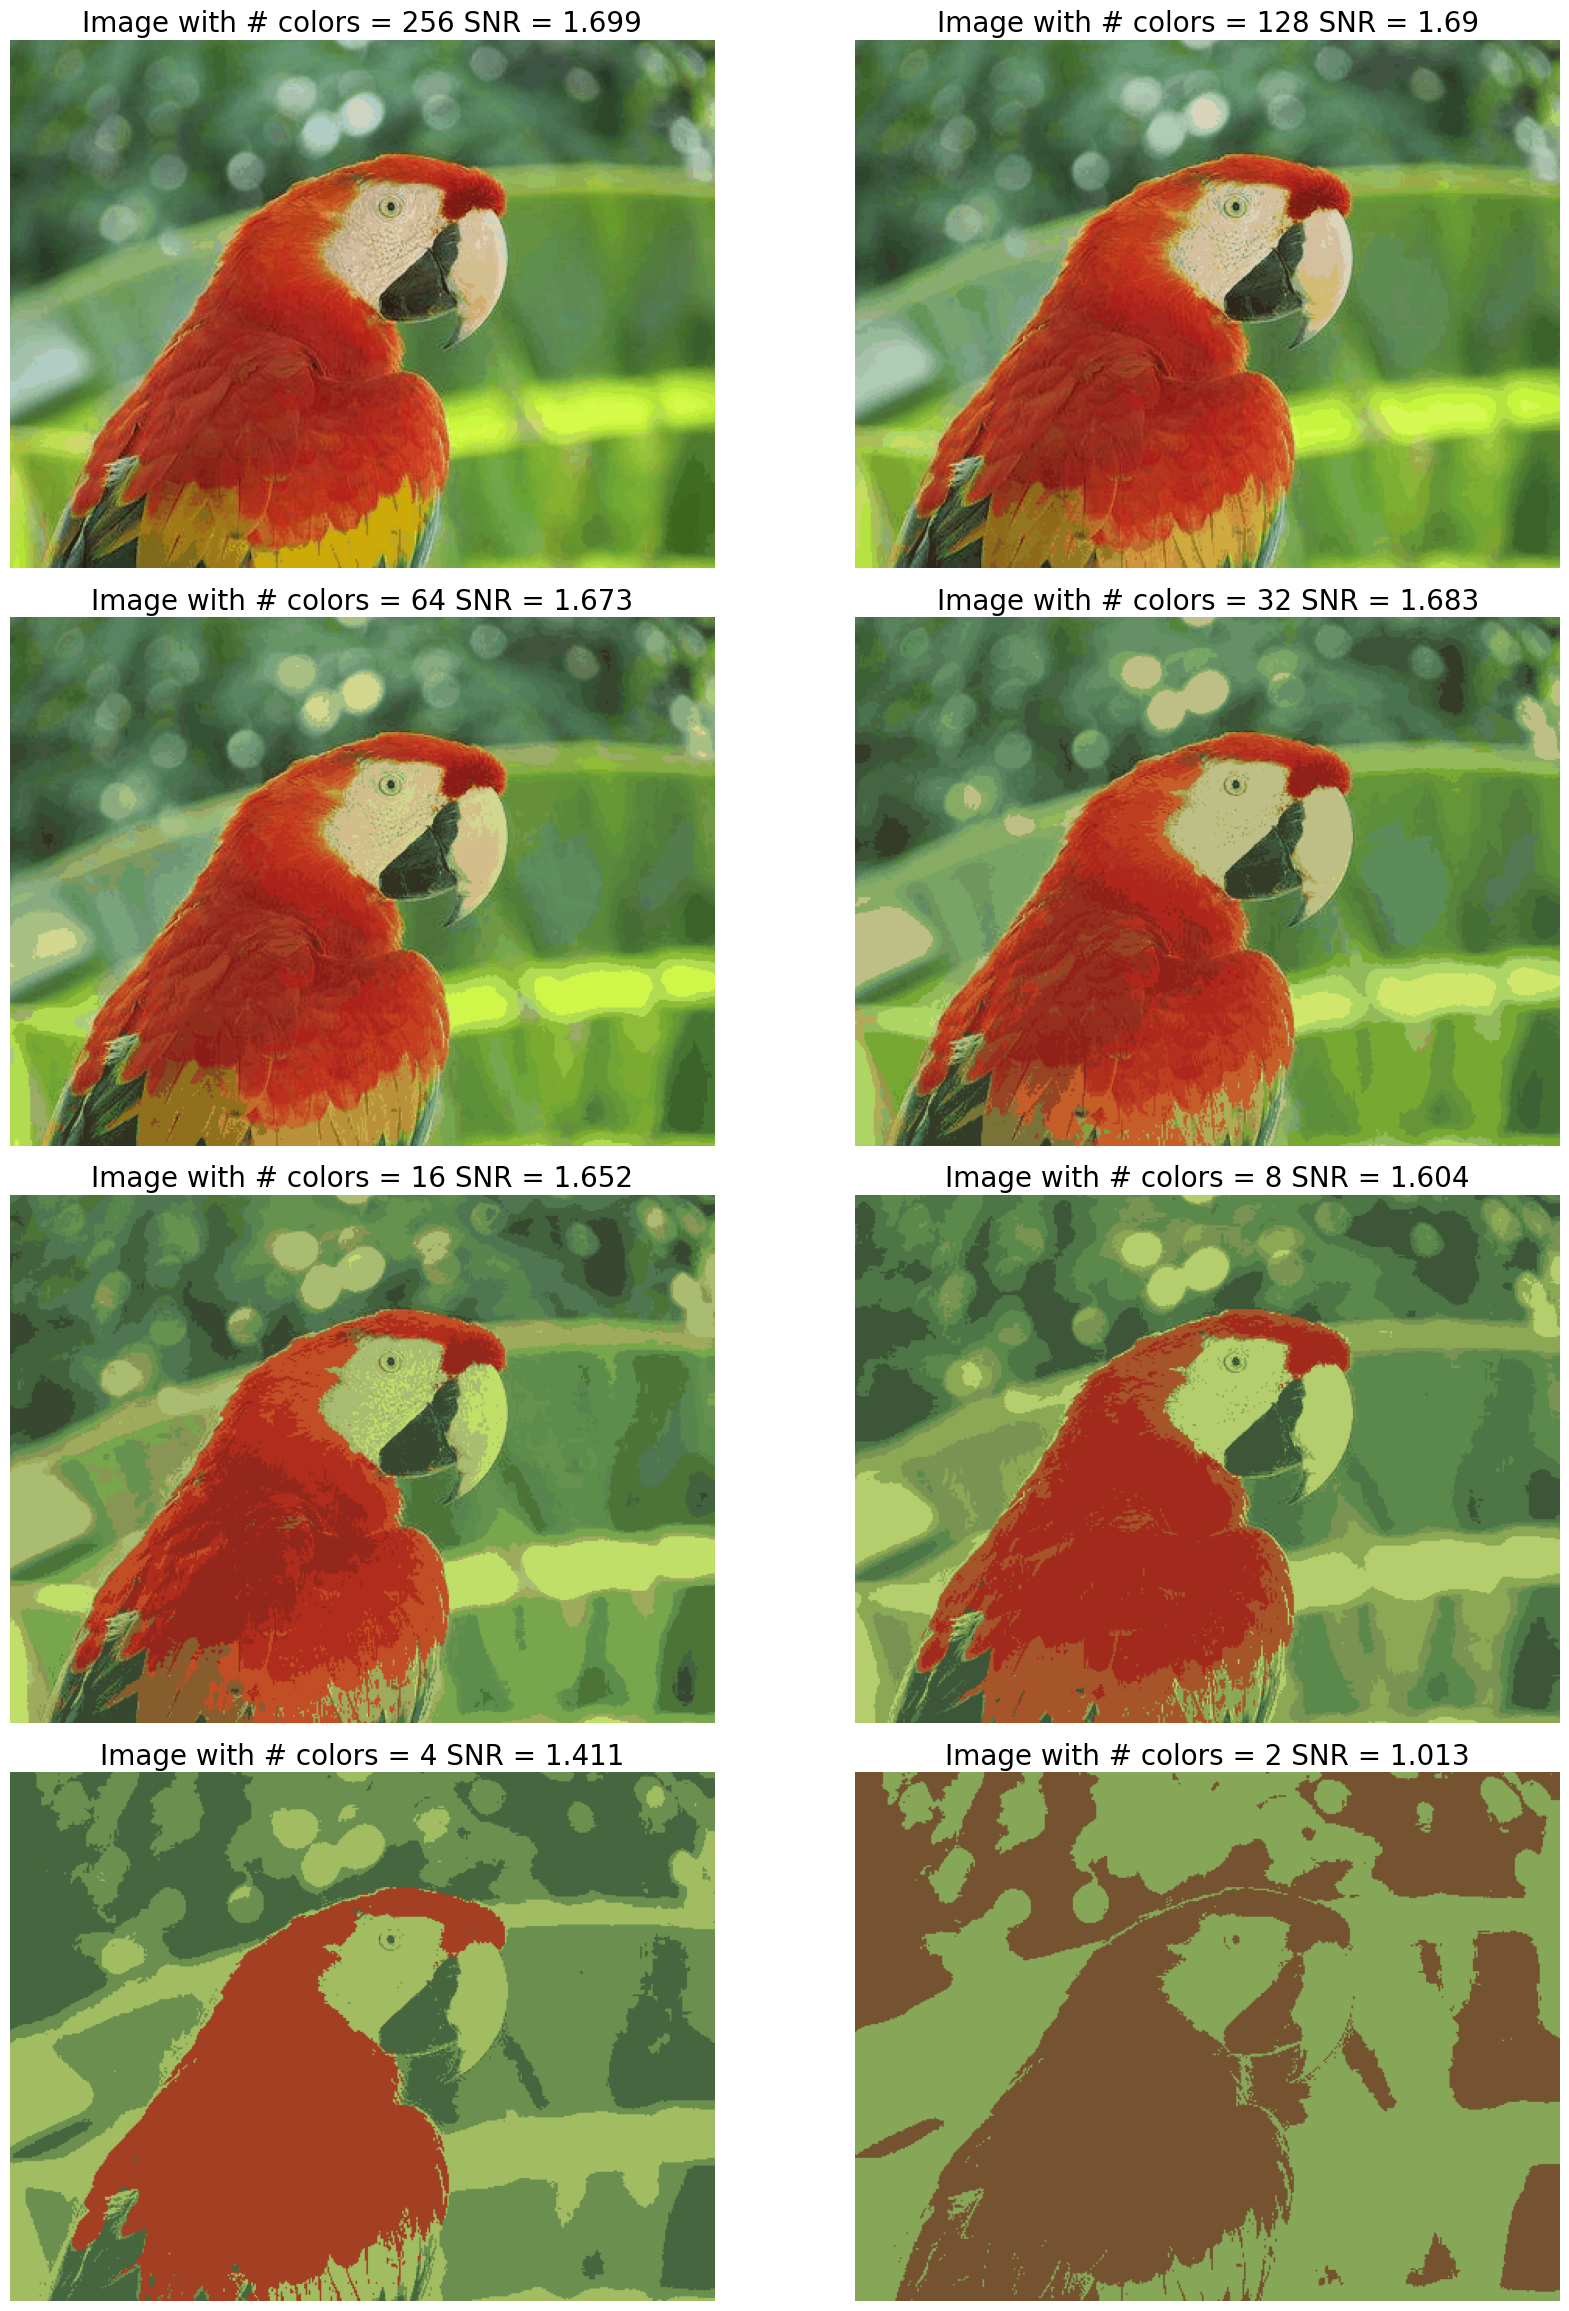

In [ ]:
im = Image.open('D:\College_IIITL\Sem 2\IPCV\images\parrot.jpg')
pylab.figure(figsize=(20,30))
num_colors_list = [1 << n for n in range(8,0,-1)] #creating a list of numbers of color(color depths) to reduce the image to, the values are generated as power of 2
snr_list = []
i = 1
#loop iterates through the number of colors for processing the image for calculating the SNR for images
for num_colors in num_colors_list:
    # this is a process of quantization
    #'P' -- image is converted to indexed(paletted) format where the number of colors is reduced to num_colors
    #ADAPTIVE is used to generate the palette based on the image's most common colors
    im1 = im.convert('P', palette=Image.ADAPTIVE, colors=num_colors)
    pylab.subplot(4,2,i), pylab.imshow(im1), pylab.axis('off')
    snr_list.append(signaltonoise(im1, axis=None)) # SNR custom function is used for calculating the SNR for entire image
    pylab.title('Image with # colors = ' + str(num_colors) + ' SNR = ' +str(np.round(snr_list[i-1],3)), size=20)
    i += 1  #increment the subplot index for next image
pylab.subplots_adjust(wspace=0.2, hspace=0)
pylab.show()

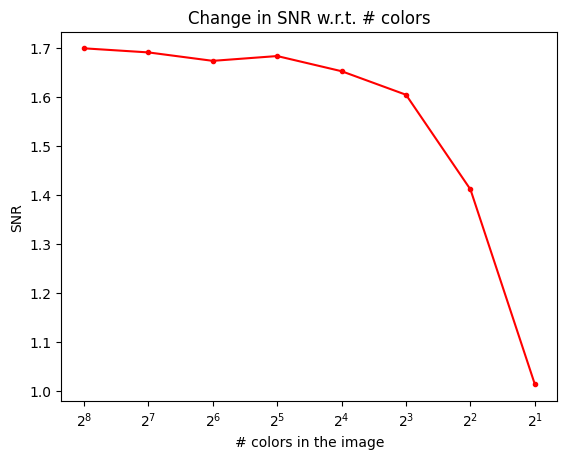

In [ ]:
# the graph is used to represent the as the number of colors decreases, the SNR may decrease as well
# this indicates that the fewer colors means there is more noise
pylab.plot(num_colors_list, snr_list, 'r.-')
pylab.xlabel('# colors in the image')
pylab.ylabel('SNR')
pylab.title('Change in SNR w.r.t. # colors')
# pylab.xscale('log', basex=2)
pylab.xscale('log', base=2) # the x-axis is set to logarithmic scale with base 2
pylab.gca().invert_xaxis()
pylab.show()